# Correlation


- Which features predict high spending?
- What's connected to satisfaction?
- Find hidden relationships in data
- Create a "drivers of revenue" analysis

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load the cleaned data 

df = pd.read_csv("../data/cleaned_ecommerece.csv")
df.shape

(348, 11)

In [4]:
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'membership_type',
       'total_spend', 'items_purchased', 'average_rating', 'discount_applied',
       'days_since_last_purchase', 'satisfaction_level'],
      dtype='object')

In [6]:
df.describe(include="object")

,gender,city,membership_type,satisfaction_level
count,348,348,348,348
unique,2,6,3,3
top,Male,New York,Gold,Satisfied
freq,175,59,117,125


In [8]:

# Create a copy for analysis
df_corr = df.copy()

# Convert categorical variables to numerical codes
print("Converting categorical variables to numbers...")
print()

# Gender: Male=1, Female=0
df_corr['gender_code'] = (df_corr['gender'] == 'Male').astype(int)
print("gender → gender_code (Male=1, Female=0)")

# Membership type: Bronze=1, Silver=2, Gold=3
membership_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
df_corr['membership_code'] = df_corr['membership_type'].map(membership_map)
print(" membership_type → membership_code (Bronze=1, Silver=2, Gold=3)")

# Satisfaction: Unsatisfied=1, Neutral=2, Satisfied=3
satisfaction_map = {'Unsatisfied': 1, 'Neutral': 2, 'Satisfied': 3}
df_corr['satisfaction_code'] = df_corr['satisfaction_level'].map(satisfaction_map)
print("satisfaction_level → satisfaction_code (Unsatisfied=1, Neutral=2, Satisfied=3)")

# Discount applied: Already boolean (True/False), convert to 1/0
df_corr['discount_code'] = df_corr['discount_applied'].astype(int)
print("discount_applied → discount_code (Yes=1, No=0)")

print()

# Select numerical columns for correlation
numerical_cols = ['age', 'total_spend', 'items_purchased', 'average_rating',
                    'days_since_last_purchase', 'gender_code', 'membership_code',
                    'satisfaction_code', 'discount_code']

df_analysis = df_corr[numerical_cols]
print(f"Selected {len(numerical_cols)} features for correlation analysis")
print()

Converting categorical variables to numbers...

gender → gender_code (Male=1, Female=0)
 membership_type → membership_code (Bronze=1, Silver=2, Gold=3)
satisfaction_level → satisfaction_code (Unsatisfied=1, Neutral=2, Satisfied=3)
discount_applied → discount_code (Yes=1, No=0)

Selected 9 features for correlation analysis



In [10]:


print("CORRELATION MATRIX")

print()

# Calculate correlation matrix
correlation_matrix = df_analysis.corr()

print("Correlation coefficients:")
print()
print(correlation_matrix.round(3))
print()



CORRELATION MATRIX

Correlation coefficients:

                            age  total_spend  items_purchased  average_rating  \
age                       1.000       -0.677           -0.684          -0.722   
total_spend              -0.677        1.000            0.972           0.941   
items_purchased          -0.684        0.972            1.000           0.921   
average_rating           -0.722        0.941            0.921           1.000   
days_since_last_purchase  0.170       -0.545           -0.425          -0.436   
gender_code              -0.582        0.387            0.439           0.493   
membership_code          -0.791        0.945            0.896           0.950   
satisfaction_code        -0.463        0.797            0.693           0.695   
discount_code             0.061       -0.169           -0.123          -0.077   

                          days_since_last_purchase  gender_code  \
age                                          0.170       -0.582   
total_sp

Creating correlation heatmap...


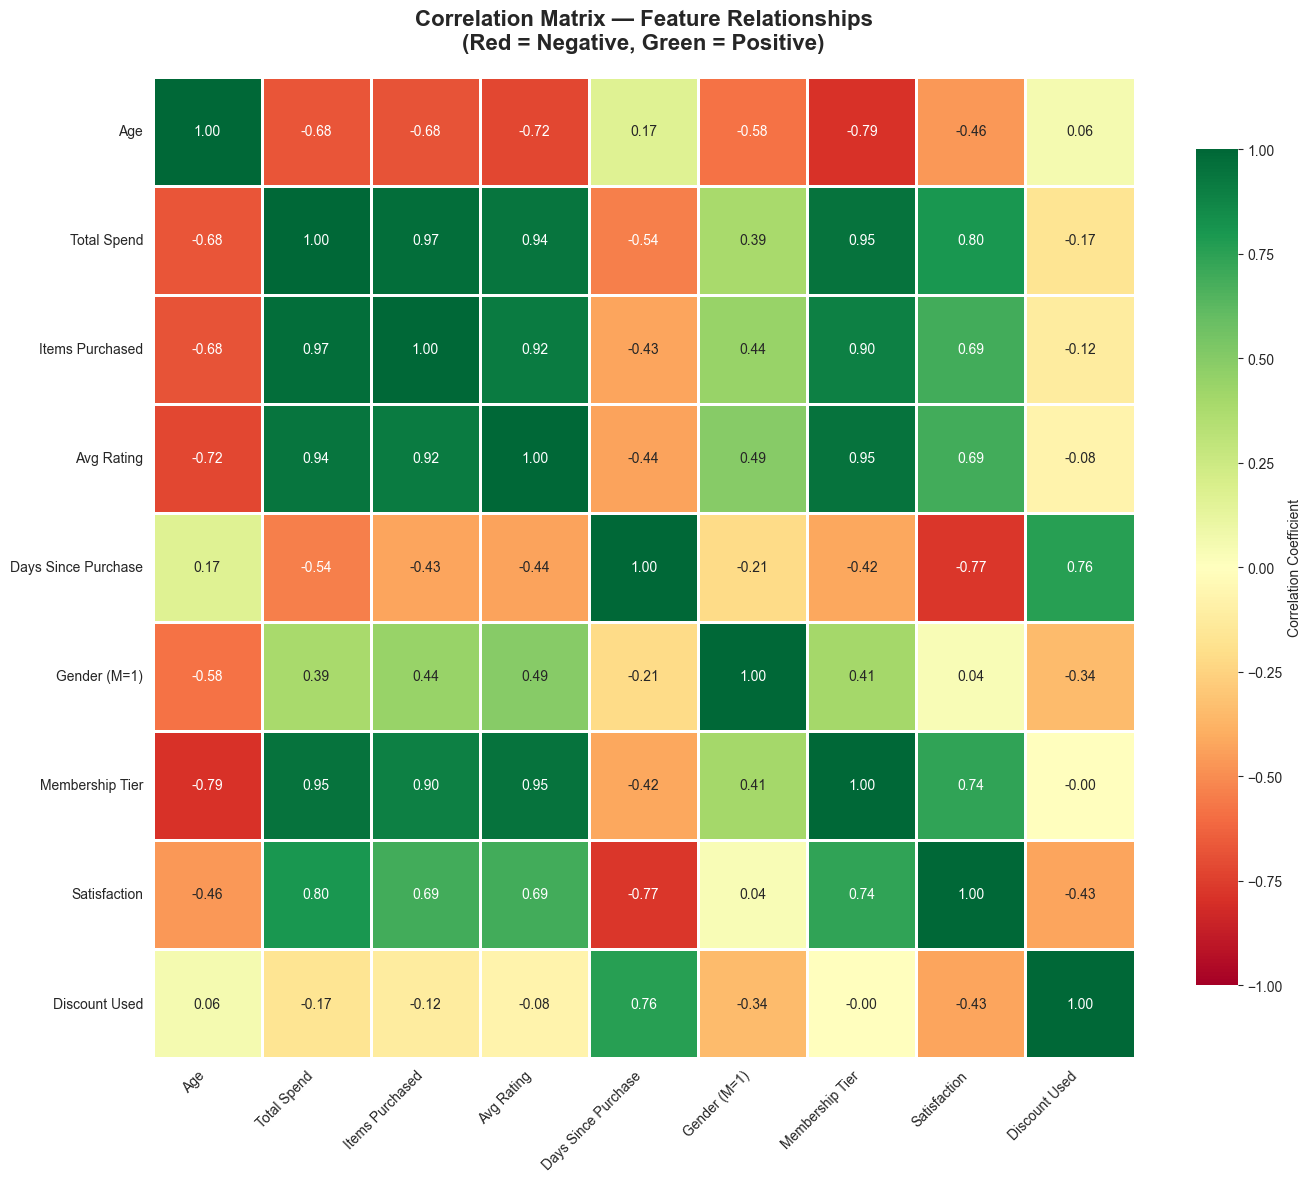

In [11]:
print("Creating correlation heatmap...")

# Create a large figure
plt.figure(figsize=(14, 12))

# Create heatmap with better labels
correlation_matrix_labeled = df_analysis.corr()

# Rename columns for better readability in chart
label_map = {
    'age': 'Age',
    'total_spend': 'Total Spend',
    'items_purchased': 'Items Purchased',
    'average_rating': 'Avg Rating',
    'days_since_last_purchase': 'Days Since Purchase',
    'gender_code': 'Gender (M=1)',
    'membership_code': 'Membership Tier',
    'satisfaction_code': 'Satisfaction',
    'discount_code': 'Discount Used'
}

correlation_matrix_labeled.index = [label_map.get(x, x) for x in correlation_matrix_labeled.index]
correlation_matrix_labeled.columns = [label_map.get(x, x) for x in correlation_matrix_labeled.columns]

# Create heatmap
sns.heatmap(correlation_matrix_labeled,
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='RdYlGn',        # Red-Yellow-Green color scheme
            center=0,             # Center at 0
            square=True,          # Square cells
            linewidths=1,         # White lines between cells
            linecolor='white',
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            vmin=-1, vmax=1)      # Scale from -1 to +1

plt.title('Correlation Matrix — Feature Relationships\n(Red = Negative, Green = Positive)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/13_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:


print("=" * 70)
print("STRONGEST CORRELATIONS")
print("=" * 70)
print()

# Get upper triangle of correlation matrix (avoid duplicates)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
correlation_pairs = correlation_matrix.where(mask).stack().reset_index()
correlation_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Sort by absolute correlation strength
correlation_pairs['Abs_Correlation'] = correlation_pairs['Correlation'].abs()
correlation_pairs = correlation_pairs.sort_values('Abs_Correlation', ascending=False)

# Filter out perfect correlations (1.0) and weak correlations (<0.2)
correlation_pairs = correlation_pairs[
    (correlation_pairs['Abs_Correlation'] < 0.99) & 
    (correlation_pairs['Abs_Correlation'] > 0.2)
]

print("TOP 10 STRONGEST RELATIONSHIPS:")
print("-" * 70)
print()

for idx, row in correlation_pairs.head(10).iterrows():
    feat1 = row['Feature_1']
    feat2 = row['Feature_2']
    corr = row['Correlation']
    
    # Interpret strength
    if abs(corr) > 0.7:
        strength = "VERY STRONG"
        emoji = "🔥"
    elif abs(corr) > 0.5:
        strength = "STRONG"
        emoji = "💪"
    elif abs(corr) > 0.3:
        strength = "MODERATE"
        emoji = "👍"
    else:
        strength = "WEAK"
        emoji = "🤏"
    
    # Interpret direction
    if corr > 0:
        direction = "POSITIVE"
        arrow = "↗️"
        meaning = "When one increases, the other increases"
    else:
        direction = "NEGATIVE"
        arrow = "↘️"
        meaning = "When one increases, the other decreases"
    
    print(f"{emoji} {feat1} ↔ {feat2}")
    print(f"   Correlation: {corr:.3f} ({strength} {direction})")
    print(f"   {arrow} {meaning}")
    print()

print("=" * 70)

🎯 STRONGEST CORRELATIONS

TOP 10 STRONGEST RELATIONSHIPS:
----------------------------------------------------------------------

🔥 total_spend ↔ items_purchased
   Correlation: 0.972 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 average_rating ↔ membership_code
   Correlation: 0.950 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 total_spend ↔ membership_code
   Correlation: 0.945 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 total_spend ↔ average_rating
   Correlation: 0.941 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 items_purchased ↔ average_rating
   Correlation: 0.921 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 items_purchased ↔ membership_code
   Correlation: 0.896 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 total_spend ↔ satisfaction_code
   Correlation: 0.797 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other in

In [13]:

print("=" * 70)
print("💰 WHAT DRIVES CUSTOMER SPENDING?")
print("=" * 70)
print()

# Get correlations with total_spend
spend_correlations = correlation_matrix['total_spend'].sort_values(ascending=False)

# Remove total_spend itself
spend_correlations = spend_correlations.drop('total_spend')

print("CORRELATION WITH TOTAL SPEND:")
print("-" * 70)
print()

for feature, corr in spend_correlations.items():
    # Get original feature name
    original_name = {
        'age': 'Customer Age',
        'items_purchased': 'Items Purchased',
        'average_rating': 'Average Rating',
        'days_since_last_purchase': 'Days Since Last Purchase',
        'gender_code': 'Gender',
        'membership_code': 'Membership Tier',
        'satisfaction_code': 'Satisfaction Level',
        'discount_code': 'Discount Usage'
    }.get(feature, feature)
    
    # Interpret
    if abs(corr) > 0.5:
        emoji = "🔥"
        level = "STRONG"
    elif abs(corr) > 0.3:
        emoji = "💪"
        level = "MODERATE"
    elif abs(corr) > 0.1:
        emoji = "👍"
        level = "WEAK"
    else:
        emoji = "🤷"
        level = "VERY WEAK"
    
    if corr > 0:
        impact = "INCREASES spending"
    else:
        impact = "DECREASES spending"
    
    print(f"{emoji} {original_name:30s} {corr:+.3f} ({level})")
    print(f"   → {impact}")
    print()

print("=" * 70)

💰 WHAT DRIVES CUSTOMER SPENDING?

CORRELATION WITH TOTAL SPEND:
----------------------------------------------------------------------

🔥 Items Purchased                +0.972 (STRONG)
   → INCREASES spending

🔥 Membership Tier                +0.945 (STRONG)
   → INCREASES spending

🔥 Average Rating                 +0.941 (STRONG)
   → INCREASES spending

🔥 Satisfaction Level             +0.797 (STRONG)
   → INCREASES spending

💪 Gender                         +0.387 (MODERATE)
   → INCREASES spending

👍 Discount Usage                 -0.169 (WEAK)
   → DECREASES spending

🔥 Days Since Last Purchase       -0.545 (STRONG)
   → DECREASES spending

🔥 Customer Age                   -0.677 (STRONG)
   → DECREASES spending



Creating scatter plots for key relationships...


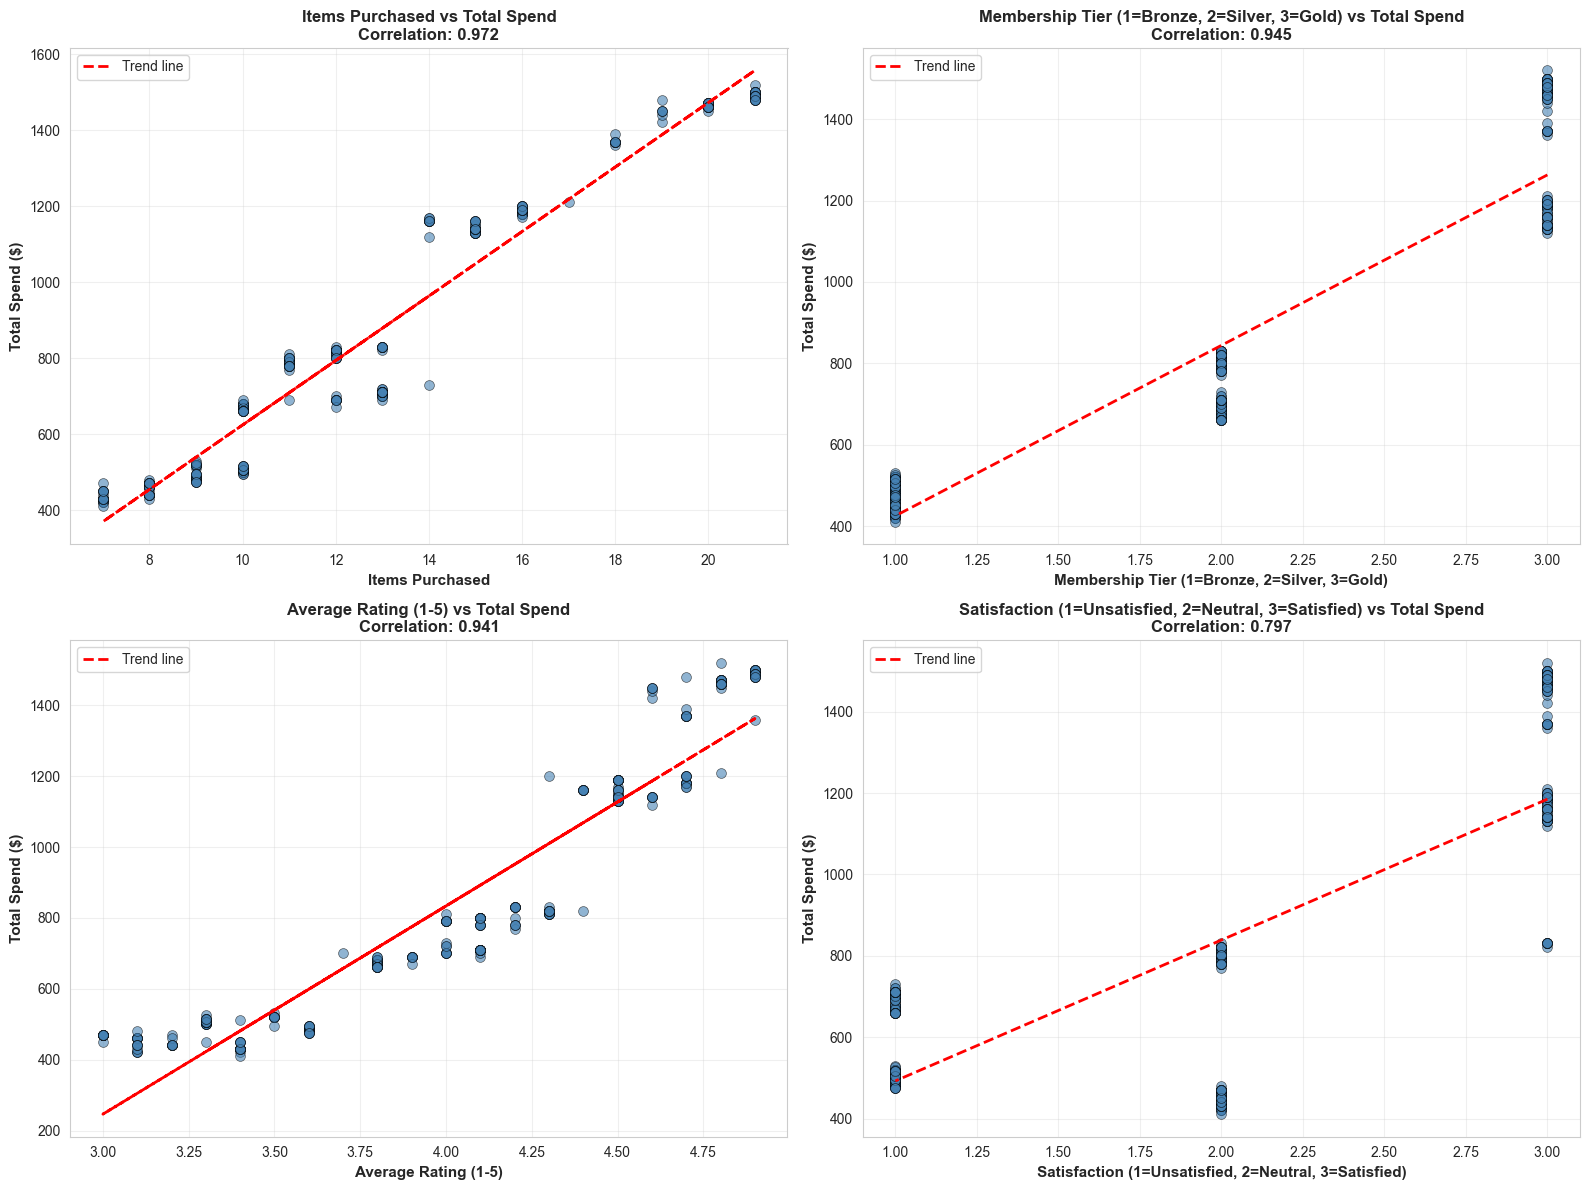

✅ Scatter plots saved!



In [14]:


print("Creating scatter plots for key relationships...")

# Get top 4 correlations with total_spend (excluding itself)
top_features = spend_correlations.abs().nlargest(4).index.tolist()

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    # Create scatter plot
    axes[idx].scatter(df_analysis[feature], df_analysis['total_spend'],
                     alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(df_analysis[feature], df_analysis['total_spend'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_analysis[feature], p(df_analysis[feature]), 
                  "r--", linewidth=2, label='Trend line')
    
    # Get correlation
    corr = correlation_matrix.loc[feature, 'total_spend']
    
    # Labels
    feature_names = {
        'age': 'Age (years)',
        'items_purchased': 'Items Purchased',
        'average_rating': 'Average Rating (1-5)',
        'days_since_last_purchase': 'Days Since Last Purchase',
        'membership_code': 'Membership Tier (1=Bronze, 2=Silver, 3=Gold)',
        'satisfaction_code': 'Satisfaction (1=Unsatisfied, 2=Neutral, 3=Satisfied)',
        'discount_code': 'Discount (0=No, 1=Yes)',
        'gender_code': 'Gender (0=Female, 1=Male)'
    }
    
    x_label = feature_names.get(feature, feature)
    
    axes[idx].set_xlabel(x_label, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Total Spend ($)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{x_label} vs Total Spend\nCorrelation: {corr:.3f}',
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../reports/figures/14_spending_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scatter plots saved!")
print()